## **The Evolution of Shot Selection in the NBA: Shot Zones Over Time By Position**

Project Description:

This notebook explores how shot selection in the NBA has evolved over time. It also examines how this differs across player positions. Using detailed shot-location data combined with player metadata we next look at how the distribution of shots taken in  designated zones of “the paint”, “mid-range”, and “three-point” areas has changed from the turn of the century to the present.


Table of Contents:
1. Imports and Environments
2. Data Cleaning and Manipulation
3. Descriptive Statistics
4. Visualizations
5. Hypothesis Testing
6. Conclusions

### Imports and Environment

In [1]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.0/319.0 kB 6.1 MB/s eta 0:00:00


In [2]:
# Used to convert Unicode to ASCII
!pip install Unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 3.6 MB/s eta 0:00:00


In [3]:
from nba_api.stats.endpoints import shotchartdetail
#from nba_api.stats.static import players
#from nba_api.stats.library.http import NBAStatsHTTP
#NBAStatsHTTP.timeout = 120

import pandas as pd
import numpy as np
import time
from unidecode import unidecode

In [4]:
# Visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

In [5]:
# Record dependencies and export to requirements.txt
!pip freeze > requirements.txt

In [6]:
#Should be downloaded already with no need to rerun API

#shots_df = pd.read_csv("/content/shots_df.csv")
#bbr_df = pd.read_csv("/content/bbr_df.csv")
#merged_df = pd.read_csv("/content/merged_df.csv")

### Cleaning and Manipulation

In [7]:
# We are evaluating seasons from 2000 to present
seasons = [
    "2000-01","2001-02","2002-03","2003-04","2004-05",
    "2005-06","2006-07","2007-08","2008-09","2009-10",
    "2010-11","2011-12","2012-13","2013-14","2014-15",
    "2015-16","2016-17","2017-18","2018-19","2019-20",
    "2020-21","2021-22","2022-23","2023-24"
]
season_type = "Regular Season"

shots_list = []
for s in seasons:
  sc = shotchartdetail.ShotChartDetail(
      player_id = 0,
      team_id = 0,
      season_nullable = s,
      season_type_all_star= season_type,
      context_measure_simple="FGA"
  )

  # Convert to a dataframe and add season information
  df = sc.get_data_frames()[0].copy()
  df["SEASON"] = s
  df["SEASON_TYPE"] = season_type
  shots_list.append(df)

  time.sleep(2)

# Concatenate the dataframes into one
shots_df = pd.concat(shots_list, ignore_index=True)
shots_df.shape, shots_df.head()

((4808830, 26),
            GRID_TYPE     GAME_ID  GAME_EVENT_ID  PLAYER_ID       PLAYER_NAME  \
 0  Shot Chart Detail  0020000001              2         84  Latrell Sprewell   
 1  Shot Chart Detail  0020000001             11        947     Allen Iverson   
 2  Shot Chart Detail  0020000001             13        275     Allan Houston   
 3  Shot Chart Detail  0020000001             16        238       Tyrone Hill   
 4  Shot Chart Detail  0020000001             18         84  Latrell Sprewell   
 
       TEAM_ID           TEAM_NAME  PERIOD  MINUTES_REMAINING  \
 0  1610612752     New York Knicks       1                 11   
 1  1610612755  Philadelphia 76ers       1                 11   
 2  1610612752     New York Knicks       1                 10   
 3  1610612755  Philadelphia 76ers       1                 10   
 4  1610612752     New York Knicks       1                 10   
 
    SECONDS_REMAINING  ... SHOT_DISTANCE  LOC_X  LOC_Y SHOT_ATTEMPTED_FLAG  \
 0                 41  ...

In [8]:
# Define the columns we want to keep
keep_cols = [
    "SEASON",
    "PLAYER_NAME",
    "TEAM_NAME",
    "LOC_X",
    "LOC_Y",
    "SHOT_TYPE",
    "SHOT_MADE_FLAG",
    "SHOT_ZONE_BASIC"
]

# Make sure columns exist in our shots_df
keep_cols = [c for c in keep_cols if c in shots_df.columns]

shots_df = shots_df[keep_cols].copy()

# Remove shots with missing shot coordinates, track what percentage were dropped
before = shots_df.shape[0]
shots_df = shots_df.dropna(subset=["LOC_X","LOC_Y"])
after = shots_df.shape[0]
numdropped = before - after
perc = (numdropped / before) * 100
print("Dropped: ", numdropped, ", making up ", perc, " percent.")


shots_df.shape, shots_df.head(), shots_df["SEASON"].value_counts()

Dropped:  547 , making up  0.01137490824171368  percent.


((4808283, 8),
     SEASON       PLAYER_NAME           TEAM_NAME  LOC_X  LOC_Y  \
 0  2000-01  Latrell Sprewell     New York Knicks  -58.0   28.0   
 1  2000-01     Allen Iverson  Philadelphia 76ers -107.0  167.0   
 2  2000-01     Allan Houston     New York Knicks -151.0   13.0   
 3  2000-01       Tyrone Hill  Philadelphia 76ers  -94.0   17.0   
 4  2000-01  Latrell Sprewell     New York Knicks -101.0   95.0   
 
         SHOT_TYPE  SHOT_MADE_FLAG        SHOT_ZONE_BASIC  
 0  2PT Field Goal               0  In The Paint (Non-RA)  
 1  2PT Field Goal               0              Mid-Range  
 2  2PT Field Goal               0              Mid-Range  
 3  2PT Field Goal               0              Mid-Range  
 4  2PT Field Goal               0              Mid-Range  ,
 SEASON
 2018-19    219458
 2023-24    218700
 2022-23    217220
 2021-22    216722
 2017-18    211707
 2016-17    209929
 2015-16    207893
 2014-15    205550
 2013-14    204126
 2012-13    201579
 2009-10    200966
 20

In [9]:
# Map the shot zones to our three defined categories
shots_df = shots_df[shots_df["SHOT_ZONE_BASIC"] != "Backcourt"].copy()
zone_map = {
    "Restricted Area": "Paint",
    "In The Paint (Non-RA)": "Paint",
    "Mid-Range": "Mid-Range",
    "Above the Break 3": "Three",
    "Left Corner 3": "Three",
    "Right Corner 3": "Three"
}

shots_df["SHOT_ZONES"] = shots_df["SHOT_ZONE_BASIC"].map(zone_map)
shots_df.loc[shots_df["SHOT_ZONES"] == "Three", "SHOT_TYPE"] = "3PT Field Goal"
shots_df.loc[shots_df["SHOT_ZONES"].isin(["Paint", "Mid-Range"]), "SHOT_TYPE"] = "2PT Field Goal"
shots_df = shots_df.drop(columns=["SHOT_ZONE_BASIC"])

shots_df["SHOT_ZONES"].value_counts(), shots_df.head()

(SHOT_ZONES
 Paint        2247400
 Three        1297885
 Mid-Range    1253222
 Name: count, dtype: int64,
     SEASON       PLAYER_NAME           TEAM_NAME  LOC_X  LOC_Y  \
 0  2000-01  Latrell Sprewell     New York Knicks  -58.0   28.0   
 1  2000-01     Allen Iverson  Philadelphia 76ers -107.0  167.0   
 2  2000-01     Allan Houston     New York Knicks -151.0   13.0   
 3  2000-01       Tyrone Hill  Philadelphia 76ers  -94.0   17.0   
 4  2000-01  Latrell Sprewell     New York Knicks -101.0   95.0   
 
         SHOT_TYPE  SHOT_MADE_FLAG SHOT_ZONES  
 0  2PT Field Goal               0      Paint  
 1  2PT Field Goal               0  Mid-Range  
 2  2PT Field Goal               0  Mid-Range  
 3  2PT Field Goal               0  Mid-Range  
 4  2PT Field Goal               0  Mid-Range  )

In [10]:
seasons = [
    "2000-01","2001-02","2002-03","2003-04","2004-05",
    "2005-06","2006-07","2007-08","2008-09","2009-10",
    "2010-11","2011-12","2012-13","2013-14","2014-15",
    "2015-16","2016-17","2017-18","2018-19","2019-20",
    "2020-21","2021-22","2022-23","2023-24"
]
end_years = list(range(2001, 2025))

player_season_rows = []

for season_str, end_year in zip(seasons, end_years):
    url = f"https://www.basketball-reference.com/leagues/NBA_{end_year}_per_game.html"
    print(f"Fetching {season_str}")

    #Download page and extract tables
    tables = pd.read_html(url)

    #Per-game player table
    df = tables[0].copy()

    #Add season to match shots_df
    df["SEASON"] = season_str

    #Clean
    df = df[df["Player"] != "Player"].copy()
    df = df[["SEASON", "Player", "Pos", "Team"]]

    player_season_rows.append(df)

    time.sleep(3.0)

bbr_raw = pd.concat(player_season_rows, ignore_index=True)
bbr_raw.head(), bbr_raw.shape

Fetching 2000-01
Fetching 2001-02
Fetching 2002-03
Fetching 2003-04
Fetching 2004-05
Fetching 2005-06
Fetching 2006-07
Fetching 2007-08
Fetching 2008-09
Fetching 2009-10
Fetching 2010-11
Fetching 2011-12
Fetching 2012-13
Fetching 2013-14
Fetching 2014-15
Fetching 2015-16
Fetching 2016-17
Fetching 2017-18
Fetching 2018-19
Fetching 2019-20
Fetching 2020-21
Fetching 2021-22
Fetching 2022-23
Fetching 2023-24


(    SEASON            Player Pos Team
 0  2000-01     Allen Iverson  SG  PHI
 1  2000-01  Jerry Stackhouse  SG  DET
 2  2000-01  Shaquille O'Neal   C  LAL
 3  2000-01       Kobe Bryant  SG  LAL
 4  2000-01      Vince Carter  SF  TOR,
 (14686, 4))

In [11]:
bbr_df = bbr_raw.copy()

#Cleaning player names
bbr_df["PLAYER_NAME"] = (
    bbr_df["Player"]
    .astype(str)
    .str.replace("*", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

# New column to track if a player played for multiple teams in a season
bbr_df["is_tot"] = (bbr_df["Team"] == "TOT").astype(int)

# Keep only the first row for each player in each season (to track their total shots)
bbr_df = (bbr_df.sort_values(["SEASON", "PLAYER_NAME", "is_tot"], ascending=[True, True, False])
          .drop_duplicates(subset=["SEASON", "PLAYER_NAME"], keep="first")
          .rename(columns={"Pos": "POS", "Team": "TEAM_BBR"})
          [["SEASON", "PLAYER_NAME", "POS", "TEAM_BBR"]])

# Map positions to POS_GROUP based on letters in their position title
bbr_df["POS_GROUP"] = np.where(
    bbr_df["POS"].str.contains("C", na=False),
    "C",
    np.where(bbr_df["POS"].str.contains("G", na=False), "G", "F"))

bbr_df.head(), bbr_df.shape



(      SEASON     PLAYER_NAME POS TEAM_BBR POS_GROUP
 348  2000-01      A.C. Green  PF      MIA         F
 266  2000-01     A.J. Guyton  PG      CHI         G
 102  2000-01     Aaron McKie  SG      PHI         G
 122  2000-01  Aaron Williams  PF      NJN         F
 446  2000-01      Adam Keefe  PF      GSW         F,
 (11679, 5))

In [12]:
shots_df.to_csv("shots_df.csv", index=False)
bbr_df.to_csv("bbr_df.csv", index=False)

from google.colab import files
files.download("shots_df.csv")
files.download("bbr_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
shots_df.head()

,SEASON,PLAYER_NAME,TEAM_NAME,LOC_X,LOC_Y,SHOT_TYPE,SHOT_MADE_FLAG,SHOT_ZONES
0,2000-01,Latrell Sprewell,New York Knicks,-58.0,28.0,2PT Field Goal,0,Paint
1,2000-01,Allen Iverson,Philadelphia 76ers,-107.0,167.0,2PT Field Goal,0,Mid-Range
2,2000-01,Allan Houston,New York Knicks,-151.0,13.0,2PT Field Goal,0,Mid-Range
3,2000-01,Tyrone Hill,Philadelphia 76ers,-94.0,17.0,2PT Field Goal,0,Mid-Range
4,2000-01,Latrell Sprewell,New York Knicks,-101.0,95.0,2PT Field Goal,0,Mid-Range


In [14]:
shots_df.shape

(4798507, 8)

In [15]:
bbr_df.head()

,SEASON,PLAYER_NAME,POS,TEAM_BBR,POS_GROUP
348,2000-01,A.C. Green,PF,MIA,F
266,2000-01,A.J. Guyton,PG,CHI,G
102,2000-01,Aaron McKie,SG,PHI,G
122,2000-01,Aaron Williams,PF,NJN,F
446,2000-01,Adam Keefe,PF,GSW,F


In [16]:
bbr_df.shape

(11679, 5)

### Combine datasets and cleaning

We standardized player names across data sources by converting them to ASCII, and then using str.replace to get rid of unnecessary characters as well as suffixes in player names

In [17]:
shots_df["CLEANED_PLAYER"] = (
    shots_df["PLAYER_NAME"]
    .map(unidecode) # convert Unicode to ASCII
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True) # Remove unnessary characters like ".", ",", "-", "'", etc
    .str.replace(r"\s+(jr|sr|ii|iii|iv)$", "", regex=True) # Remove suffixes appear in player names
)

bbr_df["CLEANED_PLAYER"] = (
    bbr_df["PLAYER_NAME"]
    .map(unidecode) # convert Unicode to ASCII
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True) # Remove unnessary characters like ".", ",", "-", "'", etc
    .str.replace(r"\s+(jr|sr|ii|iii|iv)$", "", regex=True) # Remove suffixes appear in player names
)

After standardizing player names, There were 21 player names that we could not match

In [18]:
left_over = set(shots_df['CLEANED_PLAYER']) - set(bbr_df["CLEANED_PLAYER"])
print(len(left_over))
left_over

21


{'cam reynolds',
 'clar weatherspoon',
 'flip murray',
 'ha ha',
 'ibrahim kutluay',
 'ike austin',
 'ike fontaine',
 'jeffery taylor',
 'matt hurt',
 'michael sweetney',
 'mitchell creek',
 'nate williams',
 'norman richardson',
 'pooh jeter',
 'ruben nembhard',
 'slava medvedenko',
 'sun sun',
 'trevon scott',
 'vincent edwards',
 'vincent hunter',
 'vitor faverani'}

We manually mapped eleven names that had not originally been matched but were determined to be matches by our visual inspection (primarily nicknames)

In [19]:
# Manually mapping names to resolve player name discrepancy between two datasets
manual_name = {
    "clarence weatherspoon": "clar weatherspoon",
    "isaac austin": "ike austin",
    "isaac fontaine": "ike fontaine",
    "norm richardson": "norman richardson",
    "mike sweetney": "michael sweetney",
    "jeff taylor": "jeffery taylor",
    "vince hunter": "vincent hunter",
    "cameron reynolds": "cam reynolds",
    "mitch creek": "mitchell creek",
    "vince edwards": "vincent edwards",
    "matthew hurt": "matt hurt",
}

In [20]:
# Manually fix 11 unmatched players
bbr_df["CLEANED_PLAYER"] = bbr_df["CLEANED_PLAYER"].replace(manual_name)

We found unexpected team names in the BBR dataset that included "TM" (2TM, 3TM, 4TM, and 5TM)

Out of 11,679 records, 1,451 (12.4%) were marked as 2TM-5TM. This is a comparably high proportion of data that might cause misleading information if we merge it with team information.

In [21]:
bbr_df["TEAM_BBR"].value_counts().loc[["2TM", "3TM", "4TM", "5TM"]]

,count
TEAM_BBR,
2TM,1356
3TM,92
4TM,2
5TM,1


Therefore, we decided to merge only by player and season, using team info from the shot data.


In [22]:
# Drop player name since we now have cleaned player names
# Drop team information from bbr dataset since we will use team info only from the shot data
bbr_drop = bbr_df.drop(["PLAYER_NAME","TEAM_BBR"], axis=1)

In [23]:
# Merge two datasets joining by season and cleaned player name
merged_df = shots_df.merge(bbr_drop, how="left",on=["SEASON", "CLEANED_PLAYER"])

In [24]:
merged_df

,SEASON,PLAYER_NAME,TEAM_NAME,LOC_X,LOC_Y,SHOT_TYPE,SHOT_MADE_FLAG,SHOT_ZONES,CLEANED_PLAYER,POS,POS_GROUP
0,2000-01,Latrell Sprewell,New York Knicks,-58.0,28.0,2PT Field Goal,0,Paint,latrell sprewell,SF,F
1,2000-01,Allen Iverson,Philadelphia 76ers,-107.0,167.0,2PT Field Goal,0,Mid-Range,allen iverson,SG,G
2,2000-01,Allan Houston,New York Knicks,-151.0,13.0,2PT Field Goal,0,Mid-Range,allan houston,SG,G
3,2000-01,Tyrone Hill,Philadelphia 76ers,-94.0,17.0,2PT Field Goal,0,Mid-Range,tyrone hill,PF,F
4,2000-01,Latrell Sprewell,New York Knicks,-101.0,95.0,2PT Field Goal,0,Mid-Range,latrell sprewell,SF,F
...,...,...,...,...,...,...,...,...,...,...,...
4798502,2023-24,Jalen Hood-Schifino,Los Angeles Lakers,64.0,218.0,2PT Field Goal,0,Mid-Range,jalen hoodschifino,SG,G
4798503,2023-24,Jordan Hawkins,New Orleans Pelicans,-206.0,71.0,2PT Field Goal,0,Mid-Range,jordan hawkins,SG,G
4798504,2023-24,Max Christie,Los Angeles Lakers,-15.0,115.0,2PT Field Goal,1,Paint,max christie,SG,G
4798505,2023-24,Jordan Hawkins,New Orleans Pelicans,-32.0,179.0,2PT Field Goal,0,Mid-Range,jordan hawkins,SG,G


There are 8498 rows (11 distinct player) out of 4798507 rows that failed to merge (0.18%) and were dropped

In [25]:
int(merged_df["POS"].isna().sum())

8498

In [26]:

int(merged_df["POS"].isna().sum())/len(merged_df)

0.0017709675113530105

In [27]:
merged_df.loc[merged_df["POS"].isna(),"CLEANED_PLAYER"].unique()

array(['steven smith', 'slava medvedenko', 'flip murray',
       'ibrahim kutluay', 'ha ha', 'sun sun', 'pooh jeter',
       'vitor faverani', 'ruben nembhard', 'trevon scott',
       'nate williams'], dtype=object)

In [28]:
merged_df = merged_df.dropna(subset=["POS"])

In [29]:
merged_df

,SEASON,PLAYER_NAME,TEAM_NAME,LOC_X,LOC_Y,SHOT_TYPE,SHOT_MADE_FLAG,SHOT_ZONES,CLEANED_PLAYER,POS,POS_GROUP
0,2000-01,Latrell Sprewell,New York Knicks,-58.0,28.0,2PT Field Goal,0,Paint,latrell sprewell,SF,F
1,2000-01,Allen Iverson,Philadelphia 76ers,-107.0,167.0,2PT Field Goal,0,Mid-Range,allen iverson,SG,G
2,2000-01,Allan Houston,New York Knicks,-151.0,13.0,2PT Field Goal,0,Mid-Range,allan houston,SG,G
3,2000-01,Tyrone Hill,Philadelphia 76ers,-94.0,17.0,2PT Field Goal,0,Mid-Range,tyrone hill,PF,F
4,2000-01,Latrell Sprewell,New York Knicks,-101.0,95.0,2PT Field Goal,0,Mid-Range,latrell sprewell,SF,F
...,...,...,...,...,...,...,...,...,...,...,...
4798502,2023-24,Jalen Hood-Schifino,Los Angeles Lakers,64.0,218.0,2PT Field Goal,0,Mid-Range,jalen hoodschifino,SG,G
4798503,2023-24,Jordan Hawkins,New Orleans Pelicans,-206.0,71.0,2PT Field Goal,0,Mid-Range,jordan hawkins,SG,G
4798504,2023-24,Max Christie,Los Angeles Lakers,-15.0,115.0,2PT Field Goal,1,Paint,max christie,SG,G
4798505,2023-24,Jordan Hawkins,New Orleans Pelicans,-32.0,179.0,2PT Field Goal,0,Mid-Range,jordan hawkins,SG,G


### Descriptive Statistics

#### Shooting Percentage & Accuracy By Season x Shot Zone

In [30]:
# Calculate the frequency of the shots taken by season and shot zones
shot_dist_season_zones = merged_df.groupby(["SEASON", "SHOT_ZONES"]).size().reset_index(name = "FREQ")

# Calculate the shot percentage by season and shot zones
shot_dist_season_zones["PERCENT"] = (
    shot_dist_season_zones
    .groupby("SEASON")["FREQ"]
    .transform(lambda x: x / x.sum())
)

# Calculate the shot accuracy by season and shot zones
shot_accuracy_season_zones = merged_df.groupby(['SEASON','SHOT_ZONES'])["SHOT_MADE_FLAG"].mean().reset_index(name="ACCURACY")

# Merge shot frequency and accuracy into one single dataframe
shot_season_zones = shot_dist_season_zones.merge(shot_accuracy_season_zones, on=['SEASON', "SHOT_ZONES"])

shot_season_zones

,SEASON,SHOT_ZONES,FREQ,PERCENT,ACCURACY
0,2000-01,Mid-Range,72414,0.380020,0.390767
1,2000-01,Paint,86101,0.451848,0.519971
2,2000-01,Three,32038,0.168132,0.356233
3,2001-02,Mid-Range,71408,0.372000,0.391749
4,2001-02,Paint,86098,0.448528,0.526389
...,...,...,...,...,...
67,2022-23,Paint,107394,0.495417,0.578282
68,2022-23,Three,83622,0.385755,0.362237
69,2023-24,Mid-Range,24588,0.112677,0.418619
70,2023-24,Paint,107713,0.493605,0.574128


#### Shooting Percentage & Accuracy By position Group x Shot Zone

In [31]:
# Calculate the frequency of the shots taken by season and shot zones
shot_dist_pos_group_zones = merged_df.groupby(["POS_GROUP","SHOT_ZONES"]).size().reset_index(name = "FREQ")

# Calculate the shot percentage by season and shot zones
shot_dist_pos_group_zones["PERCENT"] = (
    shot_dist_pos_group_zones
    .groupby("POS_GROUP")["FREQ"]
    .transform(lambda x: x / x.sum())
)

# Calculate the shot accuracy by season and shot zones
shot_accuracy_pos_group_zones = merged_df.groupby(["POS_GROUP",'SHOT_ZONES'])["SHOT_MADE_FLAG"].mean().reset_index(name="ACCURACY")

# Merge shot frequency and accuracy into one single dataframe
shot_pos_group_zones = shot_dist_pos_group_zones.merge(shot_accuracy_pos_group_zones, on=["POS_GROUP", "SHOT_ZONES"])

shot_pos_group_zones

,POS_GROUP,SHOT_ZONES,FREQ,PERCENT,ACCURACY
0,C,Mid-Range,171357,0.223691,0.393360
1,C,Paint,535023,0.698425,0.576452
2,C,Three,59662,0.077883,0.342463
3,F,Mid-Range,501684,0.266324,0.393756
4,F,Paint,880921,0.467646,0.552366
5,F,Three,501129,0.266030,0.357940
6,G,Mid-Range,577134,0.269659,0.401370
7,G,Paint,827933,0.386842,0.519409
8,G,Three,735166,0.343498,0.363204


### Shot Location Heatmap

This visualization uses the x and y shot coordinates (LOC_X and LOC_Y) to see how shot locations differ by individual player, player position, and Early era (2000–2005) vs Modern era (2019–2024)

#### Shot Location By Position

Guards show the strongest concentration in the three-point area. The dark blue arc is clearly shown on the heatmap. Forwards show a similar pattern to the Guards. However, it shows more balance across three-point, mid-range, and paint areas. The Centers’ heatmap clearly shows a focus in the paint area. It also shows less mid-range and three point emphasis than the other position groups.


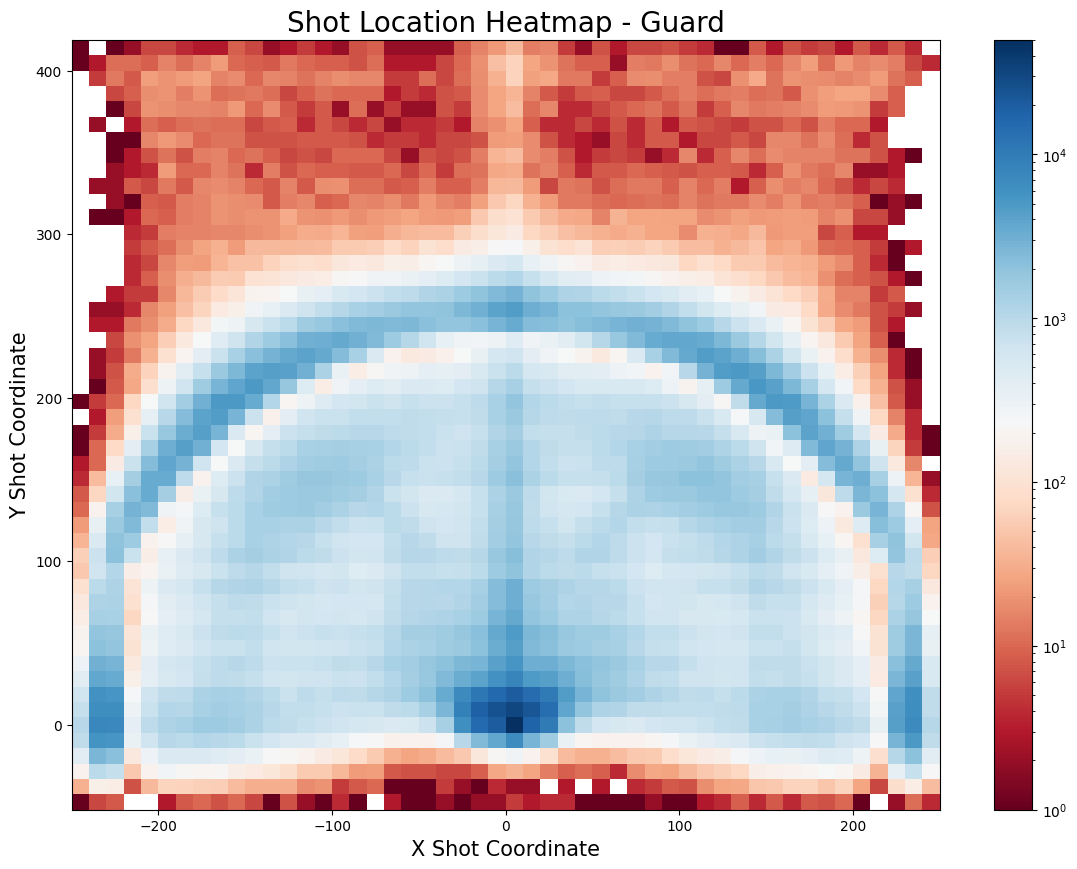

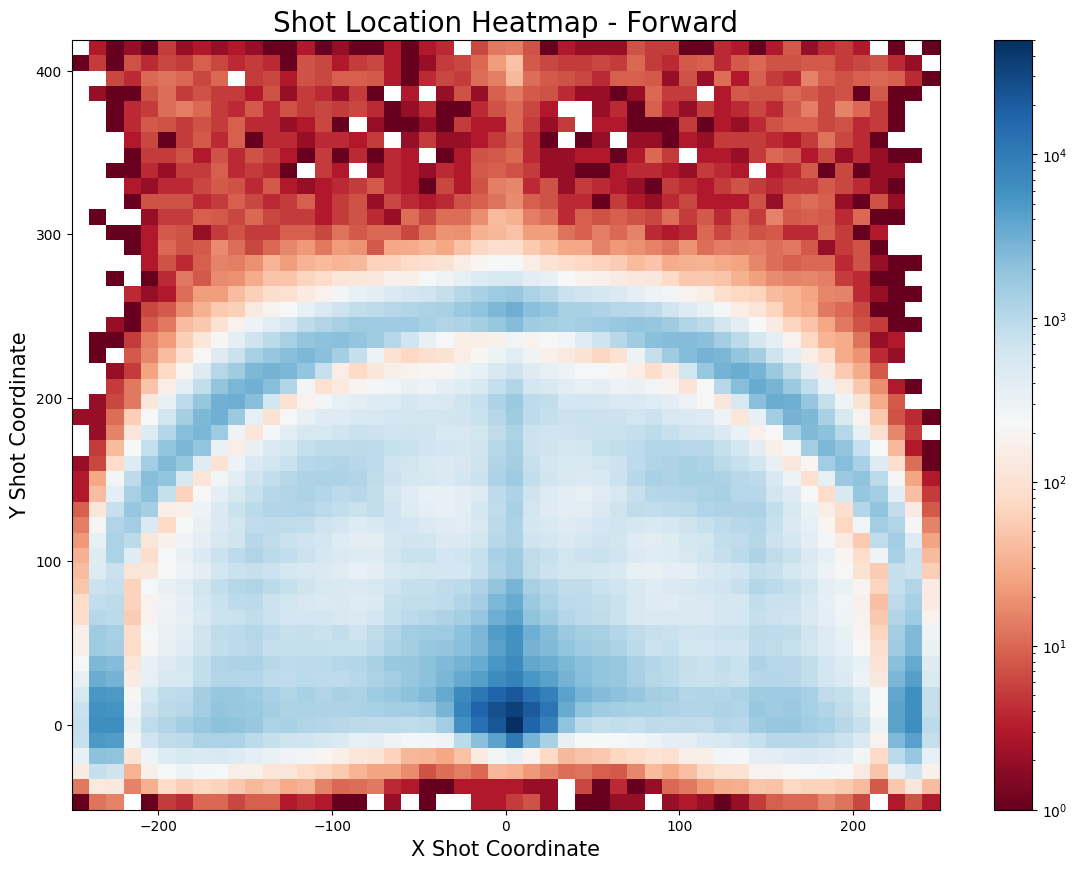

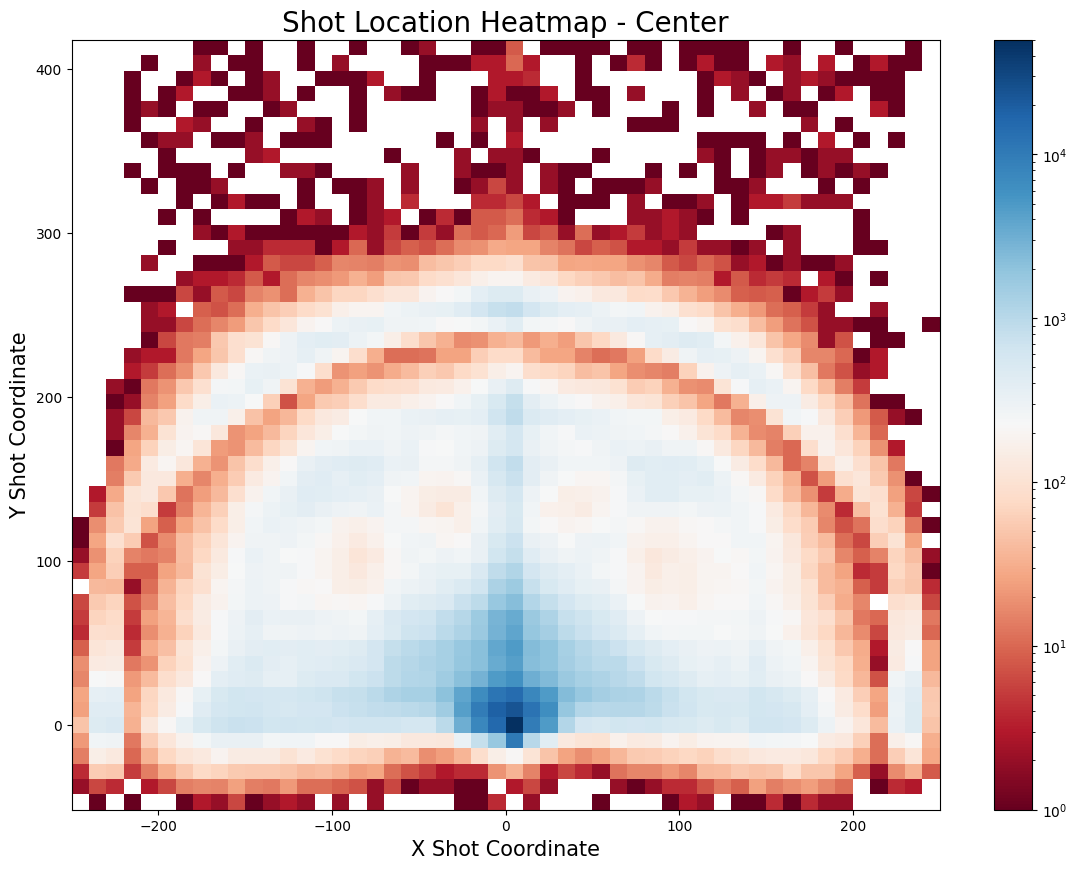

In [32]:

# Loop through each position group
for pos in ["G", "F", "C"]:

  # Create a title for each of the graphs
  title = "Shot Location Heatmap - "
  if pos == "G":
    title += "Guard"
  elif pos == "F":
    title += "Forward"
  else:
    title += "Center"

  # Filter the dataframe by position group
  position = merged_df[merged_df["POS_GROUP"] == pos]

  plt.figure(figsize=(14,10))

  # Create a 2D heatmap of shot locations by shot coordinates
  # Set norm and vmax in order to have clear visibility on distinguishing focused shot locations
  plt.hist2d(position["LOC_X"], position["LOC_Y"], bins=50, cmap="RdBu", norm="log",vmax=50000)

  # Create a color bar to show what colors represent
  plt.colorbar()

  plt.title(title, size=20)
  plt.xlabel("X Shot Coordinate", size = 15)
  plt.ylabel("Y Shot Coordinate", size = 15)
  plt.show()


#### Shot Location By Early era (2000–2005) vs Modern era (2019–2024)

The early era heatmap shows a balanced concentration of shots from three-point area, mid-range area, and near the basket. In the modern era heatmap, the heatmap pattern changes a lot. The strongest concentration is clearly along the three-point area. At the same time, the paint shows a strong concentration. However, the concentration has weakened for mid range area. So, it appears that three-point frequency has increased significantly, paint stayed in similar level, and mid-range shots have decreased significantly.



In [33]:
early_seasons = ["2000-01", "2001-02", "2002-03", "2003-04", "2004-05"]
modern_seasons = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24"]

# Create a dataframe for the early era (2000-2005) and the modern era (2019-2024)
early_df = merged_df[merged_df["SEASON"].isin(early_seasons)]
modern_df = merged_df[merged_df["SEASON"].isin(modern_seasons)]

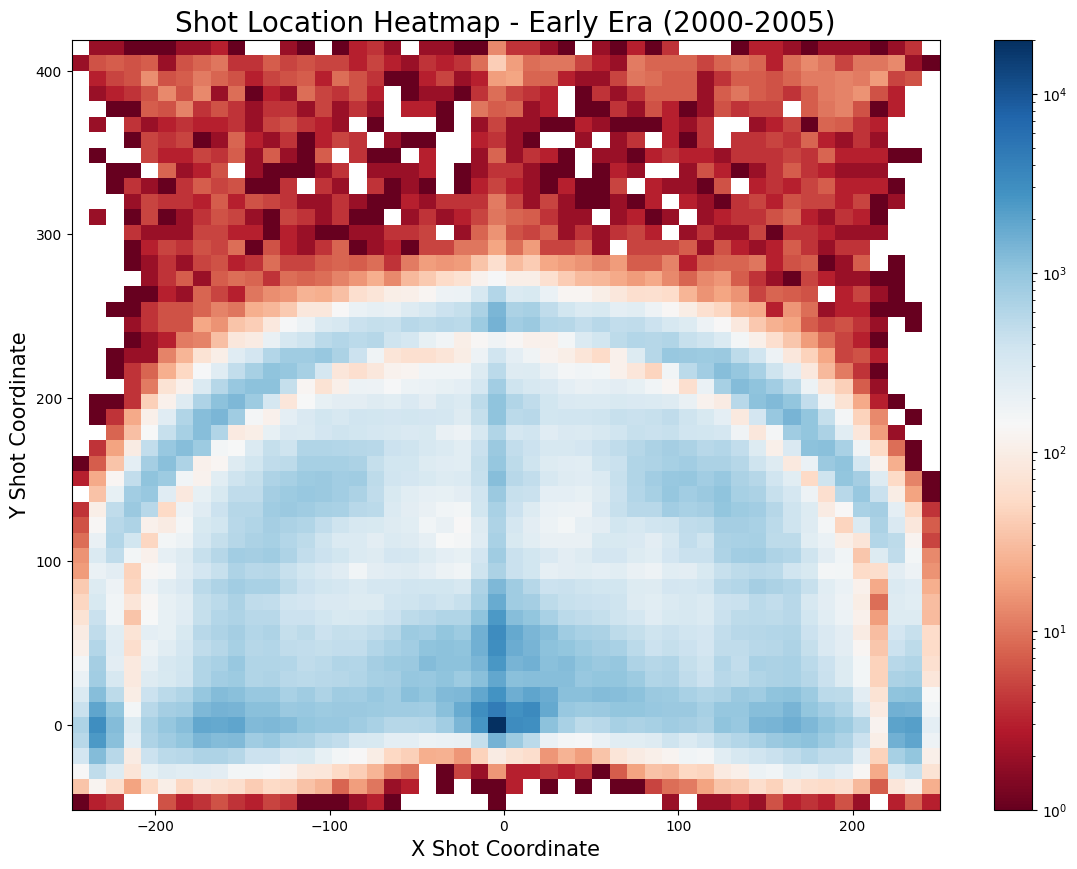

In [34]:
plt.figure(figsize=(14,10))

# Create a 2D heatmap of shot locations by shot coordinates for the early era (2000-2005)
# Set norm and vmax in order to have clear visibility on distinguishing focused shot locations
plt.hist2d(early_df["LOC_X"], early_df["LOC_Y"], bins=50, cmap="RdBu", norm="log", vmax=20000)

# Create a color bar to show what colors represent
plt.colorbar()

plt.title("Shot Location Heatmap - Early Era (2000-2005)", size=20)
plt.xlabel("X Shot Coordinate", size = 15)
plt.ylabel("Y Shot Coordinate", size = 15)
plt.show()

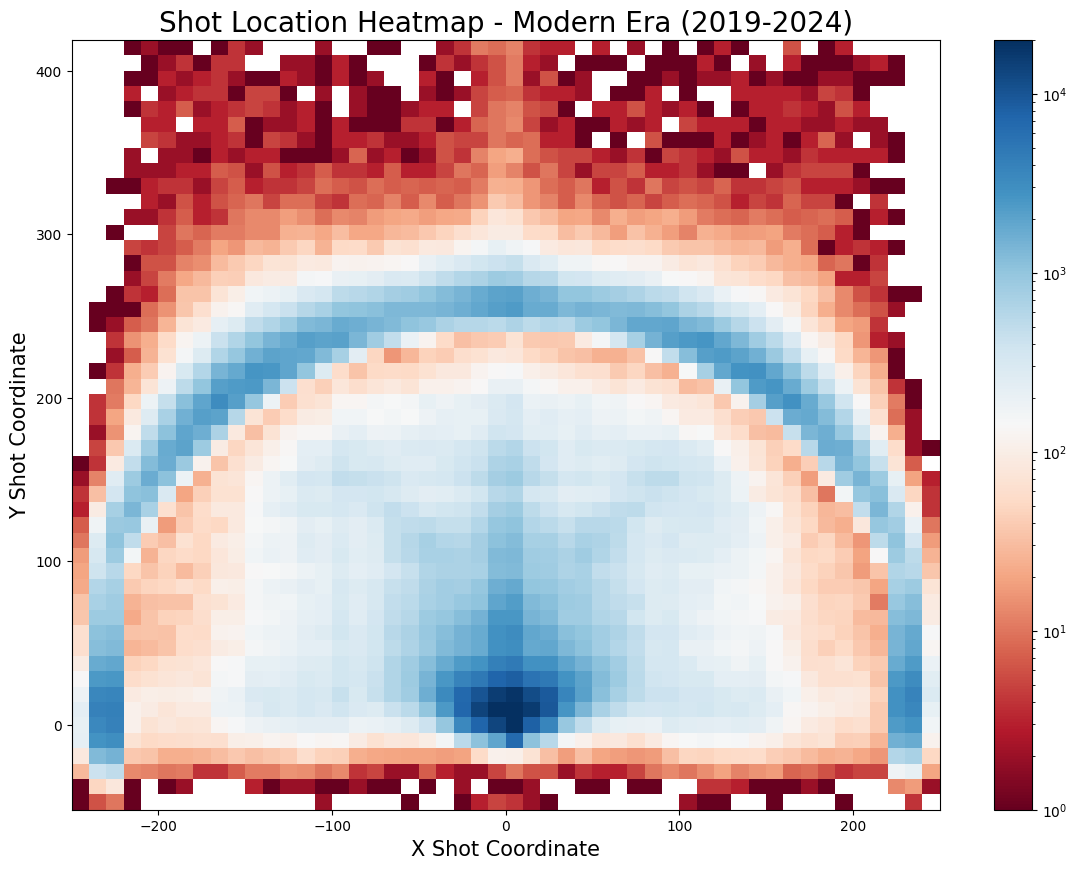

In [35]:
plt.figure(figsize=(14,10))

# Create a 2D heatmap of shot locations by shot coordinates for the early era (2019-2024)
# Set norm and vmax in order to have clear visibility on distinguishing focused shot locations
plt.hist2d(modern_df["LOC_X"], modern_df["LOC_Y"], bins=50, cmap="RdBu", norm="log", vmax=20000)

# Create a color bar to show what colors represent
plt.colorbar()

plt.title("Shot Location Heatmap - Modern Era (2019-2024)", size=20)
plt.xlabel("X Shot Coordinate", size = 15)
plt.ylabel("Y Shot Coordinate", size = 15)
plt.show()

### Stacked Bar Chart

The first stacked bar chart visualizes the shot zone proportions over seasons. Following this we break visualize the shot zones by position.

In [36]:
# Pivot so we are able to have one row per bar and one color per column

stacked = shot_dist_season_zones.pivot(
    index = "SEASON",
    columns="SHOT_ZONES",
    values="PERCENT")

stacked.head()

SHOT_ZONES,Mid-Range,Paint,Three
SEASON,,,
2000-01,0.380020,0.451848,0.168132
2001-02,0.372000,0.448528,0.179472
2002-03,0.370192,0.450001,0.179808
2003-04,0.356812,0.457881,0.185307
2004-05,0.354810,0.451201,0.193989


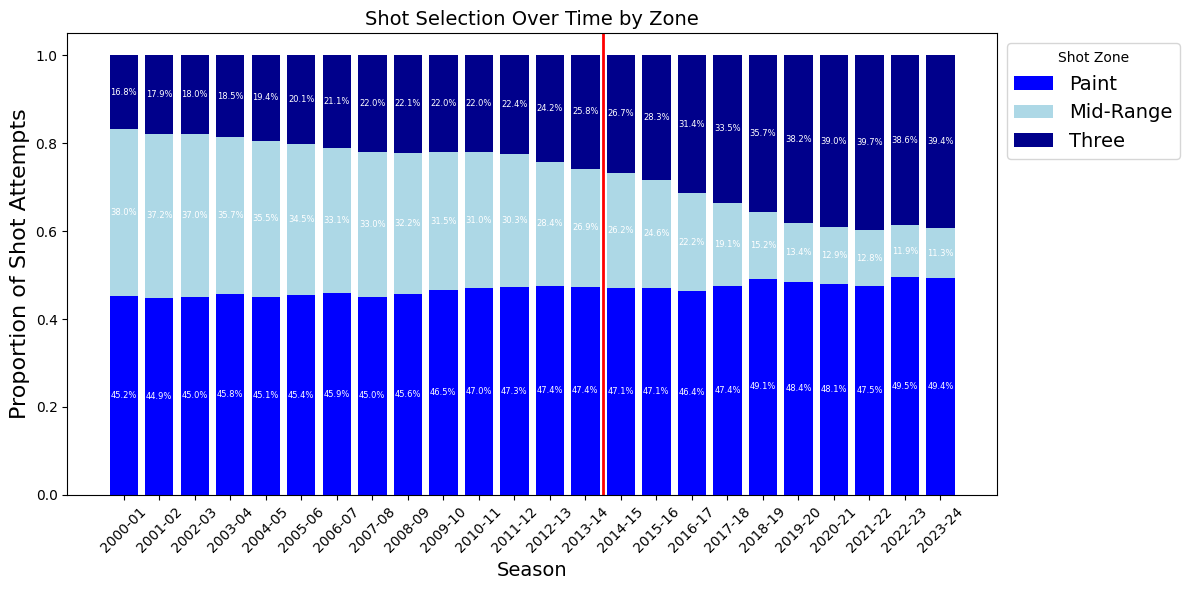

In [37]:
# Stacked bar chart for all positions combined

plt.figure(figsize=(12,6))

bottom = None

# Assign colors to the three zones
colors = {
    "Paint": "blue",
    "Mid-Range": "lightblue",
    "Three": "darkblue"
}

# We want to stack our zones in this order
zonesOrder = ["Paint", "Mid-Range", "Three"]

for shotzone in zonesOrder:
  plt.bar(stacked.index,
          stacked[shotzone],
          bottom=bottom,
          label=shotzone,
          color=colors[shotzone])

  # Add the text percentage value for each section on each bar
  for i, value in enumerate(stacked[shotzone]):
      y = (0 if bottom is None else bottom.iloc[i]) + value / 2
      plt.text(
          stacked.index[i],
          y,
          f"{value:.1%}",
          ha="center",
          va="center",
          fontsize=6,
          color="white"
      )

  # Update bottom to stack the next section of the bar at the right height
  bottom = stacked[shotzone] if bottom is None else bottom + stacked[shotzone]

# Add a vertical line between 2013-14 and 2014-15 seasons to make it easier to
# see where three point shots become more prevalent than mid-range
line = list(stacked.index).index("2013-14")
plt.axvline(x=line + 0.5, color="red", linewidth=2)

# Annotate graph
plt.title("Shot Selection Over Time by Zone", fontsize=14)
plt.xlabel("Season", fontsize=14)
plt.ylabel("Proportion of Shot Attempts", fontsize=16)
plt.legend(title="Shot Zone",
           fontsize=14,
           bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





In [38]:
# Compute shot frequency for each season, position, zone combination
shot_dist_season_pos_zones = (
    merged_df
    .groupby(["SEASON", "POS_GROUP", "SHOT_ZONES"])
    .size()
    .reset_index(name="FREQ")
)

# Calculate proportions for each season/position/zone group
shot_dist_season_pos_zones["PERCENT"] = (
    shot_dist_season_pos_zones
    .groupby(["SEASON", "POS_GROUP"])["FREQ"]
    .transform(lambda x: x / x.sum())
)

shot_dist_season_pos_zones.head()

,SEASON,POS_GROUP,SHOT_ZONES,FREQ,PERCENT
0,2000-01,C,Mid-Range,8991,0.316696
1,2000-01,C,Paint,19052,0.671081
2,2000-01,C,Three,347,0.012223
3,2000-01,F,Mid-Range,31834,0.381058
4,2000-01,F,Paint,39735,0.475635


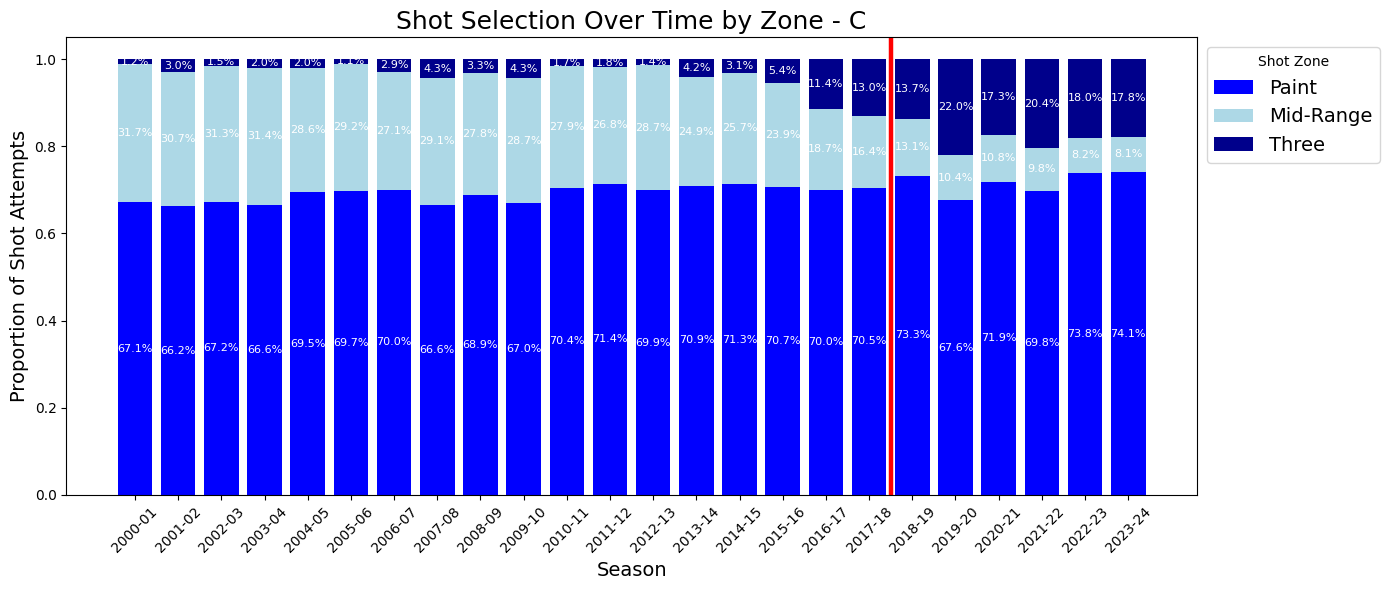

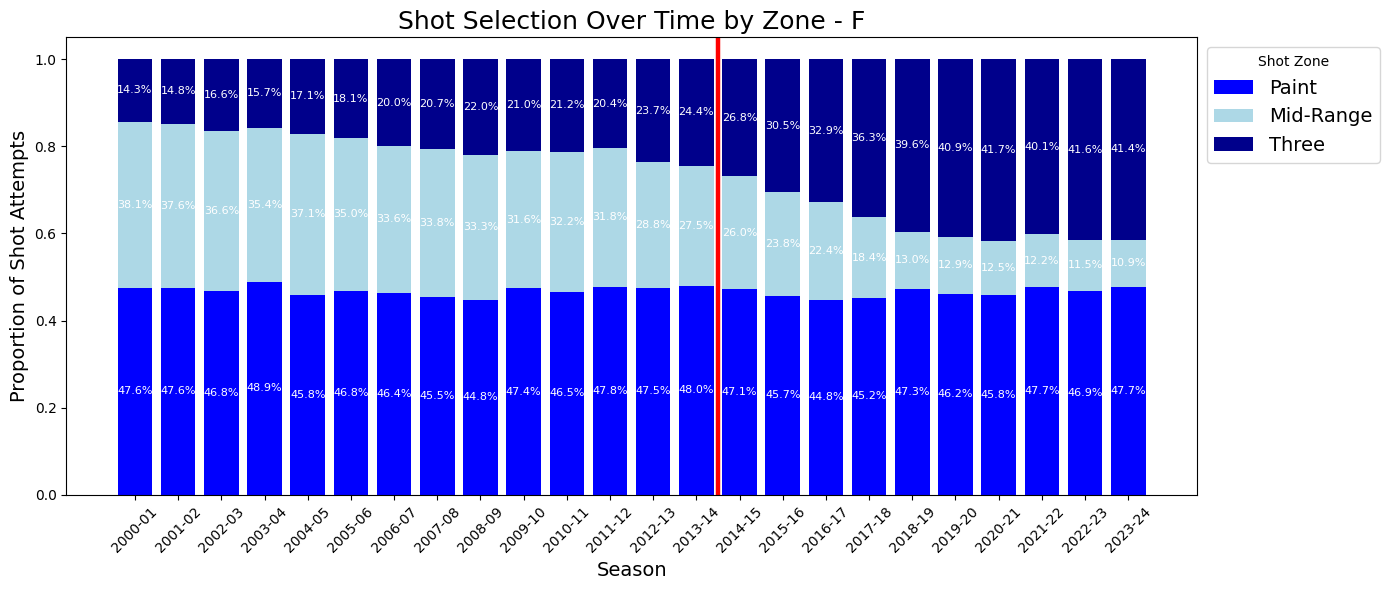

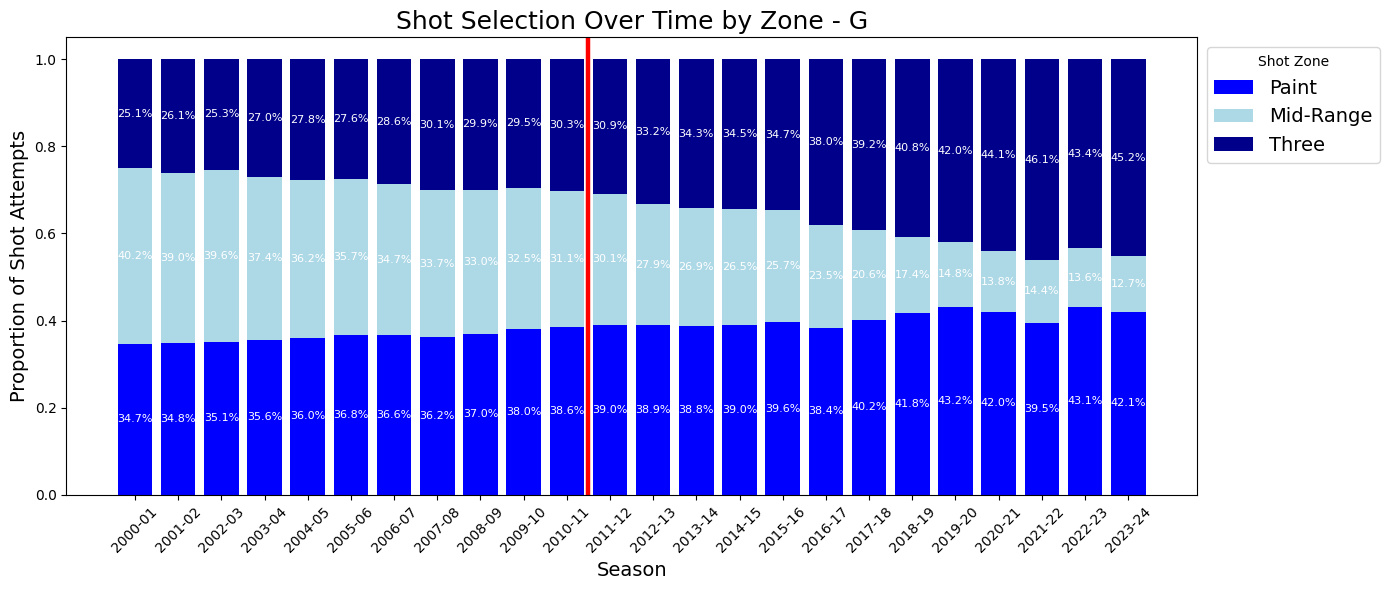

In [39]:
# Stacked bar chart by postion

# For each position (C, G, F)
position = shot_dist_season_pos_zones["POS_GROUP"].unique()

for pos in position:
  plt.figure(figsize=(14,6))

  # Only use the shots taken by that position
  position_subset = shot_dist_season_pos_zones[
      shot_dist_season_pos_zones["POS_GROUP"] == pos]

  # Pivot so that we can use each row for a bar and column for color/section
  # of the bar
  stacked_pos = position_subset.pivot(index = "SEASON",
                                      columns = "SHOT_ZONES",
                                      values="PERCENT")

  # For each zone, add the corresponding piece of the bar to the chart
  zonesOrder = ["Paint", "Mid-Range", "Three"]
  bottom = None

  for shotzone in zonesOrder:
    plt.bar(stacked_pos.index, stacked_pos[shotzone], bottom=bottom,
            label=shotzone, color=colors[shotzone])

    for i, value in enumerate(stacked_pos[shotzone]):
          y = (0 if bottom is None else bottom.iloc[i]) + value / 2
          plt.text(
              stacked_pos.index[i],
              y,
              f"{value:.1%}",
              ha="center",
              va="center",
              fontsize=8,
              color="white"
          )
    # Update bottom to stack the next section of the bar at the right height
    bottom = stacked_pos[shotzone] if bottom is None else bottom + stacked_pos[shotzone]

    # Add vertical lines to each position's chart marking the point which
    # Three-point attempts surpass Mid-Range in proportion
    if pos == "C":
      line = list(stacked.index).index("2017-18")
      plt.axvline(x=line + 0.5, color="red", linewidth=3)

    if pos == "F":
      line = list(stacked.index).index("2013-14")
      plt.axvline(x=line + 0.5, color="red", linewidth=3)

    if pos == "G":
      line = list(stacked.index).index("2010-11")
      plt.axvline(x=line + 0.5, color="red", linewidth=3)

  # Annotate graph
  plt.title(f"Shot Selection Over Time by Zone - {pos}", fontsize=18)
  plt.ylabel("Proportion of Shot Attempts", fontsize=14)
  plt.xlabel("Season", fontsize=14)
  plt.legend(title="Shot Zone",
             fontsize=14,
             bbox_to_anchor=(1, 1))
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()


### Accuracy and Points Volume: Line Charts

This visualization shows each position's trends in performance metrics (Accuracy and total point volume) within each shot zone. A 3-year rolling mean is added for the sake of noise reduction and improvement of visual clarity

In [40]:
line_chart_df = merged_df.copy()

# Point value per shot based on zone
line_chart_df["SHOT_POINTS"] = np.where(
    line_chart_df["SHOT_ZONES"] == "Three", 3, 2
)

# Points actually scored on the attempt
line_chart_df["POINTS_SCORED"] = (
    line_chart_df["SHOT_POINTS"] * line_chart_df["SHOT_MADE_FLAG"]
)

line_chart_df[["SEASON", "POS_GROUP", "SHOT_ZONES", "SHOT_MADE_FLAG", "SHOT_POINTS", "POINTS_SCORED"]].head()

,SEASON,POS_GROUP,SHOT_ZONES,SHOT_MADE_FLAG,SHOT_POINTS,POINTS_SCORED
0,2000-01,F,Paint,0,2,0
1,2000-01,G,Mid-Range,0,2,0
2,2000-01,G,Mid-Range,0,2,0
3,2000-01,F,Mid-Range,0,2,0
4,2000-01,F,Mid-Range,0,2,0


In [41]:
line_chart_summary = (
    line_chart_df
    .groupby(["SEASON", "SHOT_ZONES", "POS_GROUP"], as_index=False)
    .agg(
        SHOTS=("SHOT_MADE_FLAG", "size"),
        MAKES=("SHOT_MADE_FLAG", "sum"),
        TOTAL_POINTS=("POINTS_SCORED", "sum"),
    )
)

# Efficiency metrics
line_chart_summary["PPS"] = (
    line_chart_summary["TOTAL_POINTS"] / line_chart_summary["SHOTS"]
)

line_chart_summary["ACCURACY"] = (
    line_chart_summary["MAKES"] / line_chart_summary["SHOTS"]
)

line_chart_summary.head()

,SEASON,SHOT_ZONES,POS_GROUP,SHOTS,MAKES,TOTAL_POINTS,PPS,ACCURACY
0,2000-01,Mid-Range,C,8991,3313,6626,0.736959,0.368480
1,2000-01,Mid-Range,F,31834,12407,24814,0.779481,0.389741
2,2000-01,Mid-Range,G,31589,12577,25154,0.796290,0.398145
3,2000-01,Paint,C,19052,9985,19970,1.048184,0.524092
4,2000-01,Paint,F,39735,21053,42106,1.059670,0.529835


In [42]:
# Create a new column season start and ensure it is an integer
line_chart_summary["SEASON_START"] = (
    line_chart_summary["SEASON"].str.slice(0, 4).astype(int)
)

# Define position and zone orders
pos_order = ["G", "F", "C"]
zone_order = ["Paint", "Mid-Range", "Three"]

# Order position category with chosen order
line_chart_summary["POS_GROUP"] = pd.Categorical(
    line_chart_summary["POS_GROUP"],
    categories=pos_order,
    ordered=True
)

# Order position category with chosen position order
line_chart_summary["SHOT_ZONES"] = pd.Categorical(
    line_chart_summary["SHOT_ZONES"],
    categories=zone_order,
    ordered=True
)

# Switch to long format before plotting
line_chart_long = line_chart_summary.melt(
    id_vars=[
        "SEASON",
        "SEASON_START",
        "SHOT_ZONES",
        "POS_GROUP",
        "SHOTS",
        "MAKES"
    ],
    value_vars=["PPS", "ACCURACY", "TOTAL_POINTS"],
    var_name="METRIC",
    value_name="VALUE"
)

# Keep metrics in order for plot
line_chart_long["METRIC"] = pd.Categorical(
    line_chart_long["METRIC"],
    categories=["PPS", "ACCURACY", "TOTAL_POINTS"],
    ordered=True
)

line_chart_long.head()

,SEASON,SEASON_START,SHOT_ZONES,POS_GROUP,SHOTS,MAKES,METRIC,VALUE
0,2000-01,2000,Mid-Range,C,8991,3313,PPS,0.736959
1,2000-01,2000,Mid-Range,F,31834,12407,PPS,0.779481
2,2000-01,2000,Mid-Range,G,31589,12577,PPS,0.796290
3,2000-01,2000,Paint,C,19052,9985,PPS,1.048184
4,2000-01,2000,Paint,F,39735,21053,PPS,1.059670


In [43]:
# Smoothing with 3-year rolling mean

plot_df = line_chart_long.copy()

plot_df = (
    plot_df
    .sort_values(["SHOT_ZONES", "POS_GROUP", "METRIC", "SEASON_START"])
    .assign(
        VALUE_SMOOTH=lambda d: (
            d.groupby(
                ["SHOT_ZONES", "POS_GROUP", "METRIC"],
                observed=True
                )["VALUE"]
                .transform(
                    lambda x: x.rolling(
                        window=3,
                        center=True,
                        min_periods=1
                    ).mean()
                )
        )
    )
)

plot_df.head()


,SEASON,SEASON_START,SHOT_ZONES,POS_GROUP,SHOTS,MAKES,METRIC,VALUE,VALUE_SMOOTH
5,2000-01,2000,Paint,G,27314,13732,PPS,1.005492,1.015801
14,2001-02,2001,Paint,G,28954,14855,PPS,1.026110,1.019671
23,2002-03,2002,Paint,G,28931,14862,PPS,1.027410,1.020420
32,2003-04,2003,Paint,G,28297,14258,PPS,1.007739,1.017816
41,2004-05,2004,Paint,G,29730,15137,PPS,1.018298,1.021032


In [44]:
# We worked with PPS as well but decided to stick with just accuracy
plot_df_drop = plot_df[plot_df["METRIC"] != "PPS"].copy()

alt.data_transformers.disable_max_rows()

# Change metrics and zones to readable names
metric_labels = {
    "ACCURACY": "Accuracy (FG%)",
    "TOTAL_POINTS": "Total Points"
}

zone_labels = {
    "Paint": "Paint",
    "Mid-Range": "Mid-Range",
    "Three": "Three-Point"
}

# Create label columns with names created in the map
plot_df_drop["METRIC_LABEL"] = plot_df_drop["METRIC"].map(metric_labels)
plot_df_drop["ZONE_LABEL"] = plot_df_drop["SHOT_ZONES"].map(zone_labels)

# Base altair chart with both lines and points
base = (
    alt.Chart(plot_df_drop)
    .mark_line(interpolate="monotone", point=alt.OverlayMarkDef(size=35))
    .encode(
        x=alt.X(
            "SEASON_START:Q",
            title="Season (start year)",
            axis=alt.Axis(
                format="d",
                tickCount=6,
                labelAngle=0
            )
        ),
        y=alt.Y(
            "VALUE_SMOOTH:Q",
            title=None
        ),
        color=alt.Color(
            "POS_GROUP:N",
            title="Position Group",
            sort=["G", "F", "C"],
            scale=alt.Scale(scheme="category10")
        ),
        tooltip=[
            alt.Tooltip("SEASON:N", title="Season"),
            alt.Tooltip("ZONE_LABEL:N", title="Zone"),
            alt.Tooltip("METRIC_LABEL:N", title="Metric"),
            alt.Tooltip("POS_GROUP:N", title="Position"),
            alt.Tooltip("VALUE:Q", title="Raw Value", format=".4f"),
            alt.Tooltip("VALUE_SMOOTH:Q", title="Smoothed", format=".4f"),
        ],
    )
    .properties(width=320, height=180)
)

# Chart with row as shot zone and column as metric (Accuracy and total points)
chart = (
    base
    .facet(
        row=alt.Row(
            "ZONE_LABEL:N",
            title=None,
            sort=["Paint", "Mid-Range", "Three-Point"],
            header=alt.Header(
                labelFontSize=13,
                labelFontWeight="bold",
                labelPadding=8
            )
        ),
        column=alt.Column(
            "METRIC_LABEL:N",
            title=None,
            sort=list(metric_labels.values()),
            header=alt.Header(
                labelFontSize=13,
                labelFontWeight="bold",
                labelPadding=8
            )
        )
    )
    .resolve_scale(y="independent")
    .configure_view(stroke=None)
    .configure_axis(
        labelFontSize=11,
        titleFontSize=12,
        grid=True,
        gridOpacity=0.25
    )
    .configure_legend(
        orient="right",
        titleFontSize=12,
        labelFontSize=11,
        symbolStrokeWidth=4
    )
    .properties(
        title=alt.TitleParams(
            text="NBA Shot Zone Trends by Position (2000–2024)",
            subtitle=[
                "Shooting accuracy and total points by shot zone",
                "3-year rolling mean shown for visual clarity and noise reduction", ""
            ],
            anchor="middle",
            fontSize=22,
            subtitleFontSize=14,
            subtitlePadding=14
        )
    )
)

chart

alt.FacetChart(...)

# Hypothesis Testing

### **Hypothesis Testing Question 1**
How has the distribution of shots taken in the paint, mid-range, and three-point areas changed from the early 2000s to the present?

1.	Overall shot zone distribution (League-wide)

*   Test: Chi-square test of independence
*   Comparison: Early era (2000–2005) vs Modern era (2019–2024)
*   Variables: Shot zone (Paint, Mid-Range, Three) × Era
*   Purpose: Test whether the overall distribution of shot locations has changed over time.

⸻


Question 1:

In [45]:
# Only use early and modern seasons for Q1 testing
q1_df = merged_df[
    merged_df["SEASON"].isin(early_seasons + modern_seasons)
][["SEASON", "SHOT_ZONES"]].copy()

# Era column is created based on season
q1_df["ERA"] = np.where(
    q1_df["SEASON"].isin(early_seasons),
    "Early (2000–2005)",
    "Modern (2019–2024)"
)

q1_df.head()

,SEASON,SHOT_ZONES,ERA
0,2000-01,Paint,Early (2000–2005)
1,2000-01,Mid-Range,Early (2000–2005)
2,2000-01,Mid-Range,Early (2000–2005)
3,2000-01,Mid-Range,Early (2000–2005)
4,2000-01,Mid-Range,Early (2000–2005)


In [46]:
# Create table counting shots by era and zone
contingency_q1 = (
    q1_df
    .groupby(["ERA", "SHOT_ZONES"])
    .size()
    .unstack()
)

contingency_q1

SHOT_ZONES,Mid-Range,Paint,Three
ERA,,,
Early (2000–2005),351294,432842,173768
Modern (2019–2024),127680,500287,401668


In [47]:
from scipy.stats import chi2_contingency

# Chi square test of independence comparing early to modern era
chi2, p_value, dof, expected = chi2_contingency(contingency_q1)

# n is total number of observations
n = contingency_q1.to_numpy().sum()
# Minimum dimension of the table minus 1
min_dim = min(contingency_q1.shape) - 1

# Calculate Cramer's V
cramers_v = np.sqrt(chi2 / (n * min_dim))

# Display results of both tests
chi2, p_value, dof, cramers_v

(np.float64(197198.6220302136),
 np.float64(0.0),
 2,
 np.float64(0.31498807208985136))

The chi-square test of independence indicates that the distribution of shot locations differs significantly between the early 2000s and the modern era (x² = 197,198.6, p < .001). The effect size, measured by Cramér’s V (0.315), indicates a large and substantively meaningful shift in shot selection. This was expected given our tables and calculations throughout the project. In the early era, mid-range attempts accounted for over one-third of all shots, while three-point attempts accounted for less than one-fifth. In the modern era, mid-range attempts have declined to approximately 12%, while three-point attempts have increased to nearly 40%, with paint attempts remaining relatively stable.

### **Hypothesis Testing Question 2**
How do these shot selection trends differ across guards, forwards, and centers, and how have positional roles evolved over time?

2.	Shot zone distribution for Guards

* Test: Chi-square test of independence
* Comparison: Early vs Modern era
* Variables: Shot zone × Era (Guard shots only)
* Purpose: Test whether guards shot selection across zones has changed over time.

3.	Shot zone distribution for Forwards

* Test: Chi-square test of independence
* Comparison: Early vs Modern era
* Variables: Shot zone × Era (Forward shots only)
* Purpose: Test whether forwards shot selection across zones has changed over time.

4.	Shot zone distribution for Centers

* Test: Chi-square test of independence
* Comparison: Early vs Modern era
* Variables: Shot zone × Era (Center shots only)
* Purpose: Test whether centers shot selection across zones has changed over time.

⸻


Question 2:

In [48]:
# Only use early and modern seasons, this time include position
q2_df = merged_df[
    merged_df["SEASON"].isin(early_seasons + modern_seasons)
][["SEASON", "SHOT_ZONES", "POS_GROUP"]].copy()

# Create era column
q2_df["ERA"] = np.where(
    q2_df["SEASON"].isin(early_seasons),
    "Early (2000–2005)",
    "Modern (2019–2024)"
)

In [49]:
# Create dataframes for each position
q2_df_g = q2_df[q2_df["POS_GROUP"] == 'G']
q2_df_f = q2_df[q2_df["POS_GROUP"] == 'F']
q2_df_c = q2_df[q2_df["POS_GROUP"] == 'C']

In [50]:
# Create three tables, one per position, counting shots by era
contingency_q2_g = (
    q2_df_g
    .groupby(["ERA", "SHOT_ZONES"])
    .size()
    .unstack()
)

contingency_q2_f = (
    q2_df_f
    .groupby(["ERA", "SHOT_ZONES"])
    .size()
    .unstack()
)

contingency_q2_c = (
    q2_df_c
    .groupby(["ERA", "SHOT_ZONES"])
    .size()
    .unstack()
)

In [51]:
# Perform chi-square test and Cramer's V on the guards table,
# following the same steps as prior

chi2, p_value, dof, expected = chi2_contingency(contingency_q2_g)

n = contingency_q2_g.to_numpy().sum()
min_dim = min(contingency_q2_g.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dim))
chi2, p_value, dof, cramers_v

(np.float64(74687.67833016402),
 np.float64(0.0),
 2,
 np.float64(0.2914215201114918))

In [52]:
# Perform chi-square test and Cramer's V on the forwards table,
# following the same steps as prior
chi2, p_value, dof, expected = chi2_contingency(contingency_q2_f)

n = contingency_q2_f.to_numpy().sum()
min_dim = min(contingency_q2_f.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dim))
chi2, p_value, dof, cramers_v

(np.float64(96617.40122261585),
 np.float64(0.0),
 2,
 np.float64(0.3476383473078973))

In [53]:
# Perform chi-square test and Cramer's V on centers table,
# following the same steps as prior
chi2, p_value, dof, expected = chi2_contingency(contingency_q2_c)

n = contingency_q2_c.to_numpy().sum()
min_dim = min(contingency_q2_c.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dim))
chi2, p_value, dof, cramers_v

(np.float64(38460.34978654343),
 np.float64(0.0),
 2,
 np.float64(0.3530081491320383))

Position-specific chi-square tests of independence indicate that the distribution of shot locations differs significantly between the early 2000s and the modern era for guards, forwards, and centers (all x² tests, p < .001). Effect sizes, measured using Cramér’s V, were large across all three position groups (guards: V = 0.291; forwards: V = 0.348; centers: V = 0.353), indicating substantively meaningful shifts in shot selection over time. These results suggest that the evolution in shot selection was not specific to a single position group but instead reflected a league-wide transformation affecting all positions. Across guards, forwards, and centers, mid-range attempts declined sharply, while three-point attempts increased substantially, and paint attempts remained comparatively stable. These effects were particularly dramatic for forwards and centers, highlighting a significant evolution in positional roles and offensive responsibilities over the past two decades.

### **Hypothesis testing question 3**

Are changes in shot selection accompanied by corresponding changes in shot efficiency across different zones and positions?

5.	Paint efficiency — Points Per Shot (PPS)

* Test: Bootstrap difference in means
* Comparison: Early vs Modern era
* Variable: Points per shot (Paint shots)
* Purpose: Test whether the value of paint shot attempts has changed over time.

6.	Paint efficiency — Field Goal Percentage (FG%)

* Test: Bootstrap difference in means
* Comparison: Early vs Modern era
* Variable: Shot accuracy (Paint shots)
* Purpose: Test whether accuracy on paint shots has changed over time.

7.	Mid-range efficiency — Points Per Shot (PPS)

* Test: Bootstrap difference in means
* Comparison: Early vs Modern era
* Variable: Points per shot (Mid-Range shots)
* Purpose: Test whether the value of mid-range shot attempts has changed over time.

8.	Mid-range efficiency — Field Goal Percentage (FG%)

* Test: Bootstrap difference in means
* Comparison: Early vs Modern era
* Variable: Shot accuracy (Mid-Range shots)
* Purpose: Test whether accuracy on mid-range shots has changed over time.

9.	Three-point efficiency — Points Per Shot (PPS)

* Test: Bootstrap difference in means
* Comparison: Early vs Modern era
* Variable: Points per shot (Three-point shots)
* Purpose: Test whether the value of three-point shot attempts has changed over time.

10.	Three-point efficiency — Field Goal Percentage (FG%)

* Test: Bootstrap difference in means
* Comparison: Early vs Modern era
* Variable: Shot accuracy (Three-point shots)
* Purpose: Test whether three-point shooting accuracy has changed over time.

Question 3:

In [54]:
# Filter for only early and modern seasons
q3_df = merged_df[
    merged_df["SEASON"].isin(early_seasons + modern_seasons)
].copy()

# Create ERA column based on the season
q3_df["ERA"] = np.where(
    q3_df["SEASON"].isin(early_seasons),
    "Early (2000–2005)",
    "Modern (2019–2024)"
)

# Assign points based on the shot zone
q3_df["SHOT_POINTS"] = np.where(
    q3_df["SHOT_ZONES"] == "Three", 3, 2
)

# Calculate points scored for each shot
q3_df["POINTS_SCORED"] = (
    q3_df["SHOT_POINTS"] * q3_df["SHOT_MADE_FLAG"]
)

# Create bootstrap function for difference in means (for ERAs)
def bootstrap_diff_means(
    df,
    value_col,
    era_col="ERA",
    era_a="Early (2000–2005)",
    era_b="Modern (2019–2024)",
    n_boot=5000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    # Set a and b to values for the two eras compared
    a = df[df[era_col] == era_a][value_col].to_numpy()
    b = df[df[era_col] == era_b][value_col].to_numpy()

    # Calculate observed difference in means
    observed_diff = b.mean() - a.mean()

    # Do the bootstrap sampling
    boot_diffs = []
    for _ in range(n_boot):
        a_samp = rng.choice(a, size=len(a), replace=True)
        b_samp = rng.choice(b, size=len(b), replace=True)
        boot_diffs.append(b_samp.mean() - a_samp.mean())

    # Create 95% CI
    ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])

    return {
        "Observed_Diff": observed_diff,
        "CI_Lower": ci_lower,
        "CI_Upper": ci_upper
    }

# Track results across zones
q3_results = []

zones = ["Paint", "Mid-Range", "Three"]
metrics = {
    "PPS": "POINTS_SCORED",
    "FG%": "SHOT_MADE_FLAG"
}

# For each zone and metric, run the bootstrap analysis
for zone in zones:
    df_zone = q3_df[q3_df["SHOT_ZONES"] == zone]

    for metric_name, col in metrics.items():
        res = bootstrap_diff_means(
            df=df_zone,
            value_col=col
        )
        # Track the results in q3_results list
        q3_results.append({
            "SHOT_ZONE": zone,
            "METRIC": metric_name,
            "Observed_Diff": res["Observed_Diff"],
            "CI_Lower": res["CI_Lower"],
            "CI_Upper": res["CI_Upper"]
        })

# Create a dataframe for visualizing results
q3_results_df = pd.DataFrame(q3_results)
q3_results_df

,SHOT_ZONE,METRIC,Observed_Diff,CI_Lower,CI_Upper
0,Paint,PPS,0.086442,0.082383,0.090430
1,Paint,FG%,0.043221,0.041192,0.045215
2,Mid-Range,PPS,0.047987,0.041702,0.054224
3,Mid-Range,FG%,0.023994,0.020851,0.027112
4,Three,PPS,0.023044,0.015027,0.030960
5,Three,FG%,0.007681,0.005009,0.010320


Screenshot because bootstrap means takes a while to run

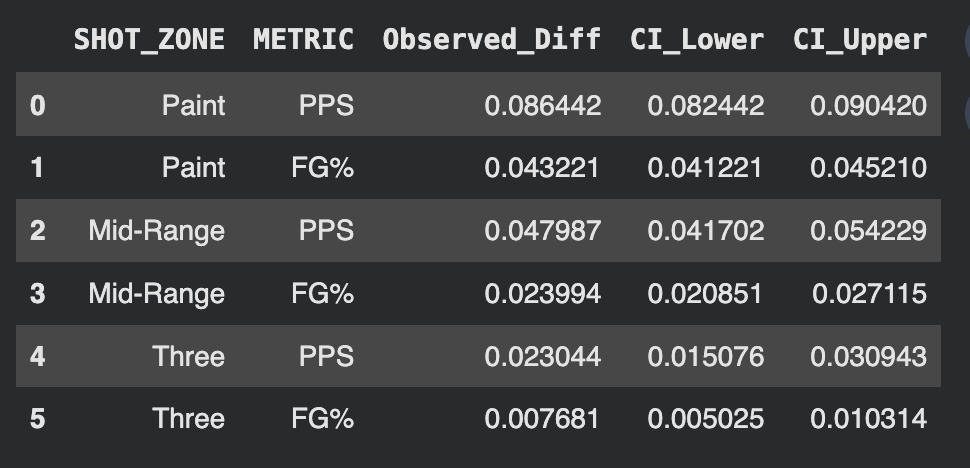


Bootstrap tests comparing early (2000–2005) and modern (2019–2024) eras indicate that shot efficiency increased across all three shot zones, as measured by both points per shot (PPS) and field goal percentage (FG%). The largest efficiency gains occurred in the paint, where PPS increased by approximately 0.086 points per attempt (95% CI: [0.082, 0.090]) and FG% increased by over four percentage points, suggesting substantial improvements in interior scoring efficiency. Mid-range shots also became more efficient, with moderate increases in both PPS and FG%, despite a pronounced decline in their overall usage, consistent with improved shot selection. Three-point efficiency increased more modestly on a per-shot basis, with smaller gains in PPS and FG%, indicating that the modern increase in three-point scoring is driven primarily by changes in shot selection rather than dramatic improvements in shooting accuracy.

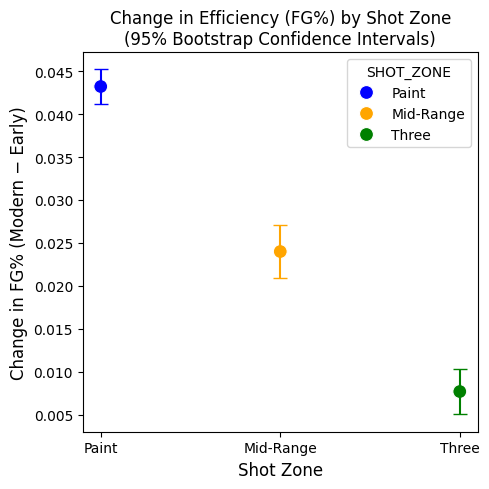

In [55]:
# Point estimate with confidence intervals

plt.figure(figsize=(5,5))

# Colors to match points on scatterplot with Confidence Intervals (CIs)
colors = {
    "Paint": "Blue",
    "Mid-Range": "Orange",
    "Three": "Green"
}

df_point = q3_results_df[q3_results_df["METRIC"] == "FG%"].copy()

# First plot the points of the change in FG%
sns.scatterplot(
    data=df_point,
    x="SHOT_ZONE",
    y="Observed_Diff",
    hue="SHOT_ZONE",
    s=100,
    palette=colors)

# Add the CIs
for i, row in df_point.iterrows():
  color = colors[row["SHOT_ZONE"]]
  plt.errorbar(
      x=row["SHOT_ZONE"],
      y=row["Observed_Diff"],
      yerr=[
          [row["Observed_Diff"] - row["CI_Lower"]],
          [row["CI_Upper"] - row["Observed_Diff"]]
      ],
      capsize=5,
      color = color
    )

# Annotate plot
plt.ylabel("Change in FG% (Modern − Early)", fontsize=12)
plt.xlabel("Shot Zone", fontsize=12)
plt.title("Change in Efficiency (FG%) by Shot Zone\n(95% Bootstrap Confidence Intervals)")
plt.tight_layout()
plt.show()




# **Conclusions**

Our results show consistent changes across eras in which shot selection has shifted away from mid-range attempts toward three-point shot attempts and shots in the paint. While field goal percentage increased across all shot zones, our bootstrap confidence intervals indicate that these gains, while non-zero, are modest in size including three-point shooting.

Driving Changes in Three Point Scoring: Our bootstrap difference in means testing allowed us to examine efficiency change between the early and modern eras, revealing a non-zero improvement in efficiency across all zones. While each zone improved in efficiency, we found the increase in efficiency was the smallest in the three point zone leading us to conclude that the modern increase in three-point scoring is driven by changes in shot selection rather than large improvements in shooting accuracy.


Our position-based analysis also reinforced these findings. All three positions have seen a proportional increase in shot attempts in the three-points zone. Centers saw a smaller magnitude of change in their three-point and mid-range total points scored than their forward and guard counterparts, but their overall trends over our time frame still reflected those of the other positions with an increase in total points made in the three-point zone over time and a decrease in total points scored in the mid-range zone over time. All three positions saw the three point zone overtake the proportion of shots in the mid-range zone. This occurred first for guards, then forwards, and finally centers. This change across all positions demonstrates that while each position may take on a role within the game, shot selection strategy has impacted the shot choices of all positions.
